# Unità 2 — BB84 con Eve: attacco intercept-resend

In questo notebook introduciamo Eve nel protocollo BB84. Eve intercetta il qubit, lo misura in una base scelta casualmente e poi reinvia a Bob un nuovo qubit coerente con il risultato della sua misura.

## Setup e import

Prepariamo il percorso del progetto in modo da poter importare le funzioni dalla cartella `src`.

In [33]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "bb84.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "bb84.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [34]:
import importlib
import pandas as pd

import bb84
import attacks

importlib.reload(bb84)
importlib.reload(attacks)

from attacks import (
    choose_eve_basis,
    eve_measure,
    eve_intercept_resend,
)

from bb84 import (
    run_bb84_round_with_eve,
    run_bb84_protocol_with_eve,
    sift_keys,
    compute_qber,
)

## Richiamo del caso ideale

Nel notebook precedente abbiamo simulato BB84 ideale. In assenza di Eve e rumore, dopo il sifting Alice e Bob ottengono la stessa chiave e il QBER è nullo.

In [35]:
results_no_eve = run_bb84_protocol_with_eve(
    n_rounds=50,
    intercept_probability=0.0,
    seed=123,
)

alice_key_no_eve, bob_key_no_eve = sift_keys(results_no_eve)
qber_no_eve = compute_qber(alice_key_no_eve, bob_key_no_eve)

print("Lunghezza della chiave sifted senza Eve:", len(alice_key_no_eve))
print("QBER senza Eve:", qber_no_eve)

Lunghezza della chiave sifted senza Eve: 22
QBER senza Eve: 0.0


## Scelta della base di Eve

Eve non conosce la base scelta da Alice. Per questo sceglie casualmente una base tra Z e X.

In [36]:
eve_basis = choose_eve_basis(seed=1)

print("Base scelta da Eve:", eve_basis)

Base scelta da Eve: Z


## Misura di Eve

Eve misura il qubit nella propria base. Se la base di Eve coincide con quella di Alice, il bit viene recuperato correttamente. Se la base è diversa, la misura introduce casualità.

In [37]:
eve_bit_same_basis = eve_measure(
    alice_bit=1,
    alice_basis="Z",
    eve_basis="Z",
)
print("Bit misurato da Eve nella stessa base:", eve_bit_same_basis)

results_eve_wrong_basis = []

for i in range(10):
    eve_bit = eve_measure(
        alice_bit=0,
        alice_basis="X",
        eve_basis="Z",
    )
    results_eve_wrong_basis.append(eve_bit)

print("Misure di Eve con base diversa:", results_eve_wrong_basis)

Bit misurato da Eve nella stessa base: 1
Misure di Eve con base diversa: [1, 0, 0, 1, 0, 1, 0, 0, 0, 1]


## Intercept-resend

Nell'attacco intercept-resend, Eve misura il qubit e poi reinvia a Bob un nuovo qubit preparato nella base e con il bit ottenuti dalla sua misura.

In [38]:
eve_result = eve_intercept_resend(
    alice_bit=1,
    alice_basis="X",
    eve_basis="Z",
)

print(eve_result)

{'eve_basis': 'Z', 'eve_bit': 1}


## Singolo round BB84 con Eve

Ora simuliamo un singolo round completo. Se Eve intercetta, Bob non riceve direttamente lo stato di Alice, ma quello ricostruito da Eve.

In [39]:
round_with_eve = run_bb84_round_with_eve(
    alice_bit=1,
    alice_basis="X",
    bob_basis="X",
    intercept_probability=1.0,
    seed=10,
)

print(round_with_eve)

{'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'X', 'bob_bit': 1, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}


## Protocollo multi-round con Eve

Ripetiamo il protocollo per più round. Per ogni round salviamo le scelte di Alice e Bob, il bit misurato da Bob e le informazioni essenziali sull'intercettazione di Eve.

In [40]:
results_with_eve = run_bb84_protocol_with_eve(
    n_rounds=50,
    intercept_probability=1.0,
    seed=123,
)

for i in range(5):
    print(results_with_eve[i])

{'round': 1, 'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 2, 'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'X', 'bob_bit': 1, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}
{'round': 3, 'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 1}
{'round': 4, 'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 5, 'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 1}


## Sifting con Eve

Anche in presenza di Eve, Alice e Bob applicano il sifting: mantengono solo i round in cui hanno scelto la stessa base.

In [41]:
alice_key_with_eve, bob_key_with_eve = sift_keys(results_with_eve)

print("Chiave di Alice con Eve:", alice_key_with_eve)
print("Chiave di Bob con Eve:", bob_key_with_eve)
print("Lunghezza della chiave sifted con Eve:", len(alice_key_with_eve))

Chiave di Alice con Eve: [1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]
Chiave di Bob con Eve: [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1]
Lunghezza della chiave sifted con Eve: 22


## QBER con Eve

Il QBER misura la frazione di errori tra la chiave di Alice e la chiave di Bob dopo il sifting. Con un attacco intercept-resend, ci si aspetta un QBER maggiore rispetto al caso ideale.

In [42]:
qber_with_eve = compute_qber(alice_key_with_eve, bob_key_with_eve)

print("QBER con Eve:", qber_with_eve)

QBER con Eve: 0.4090909090909091


## Confronto essenziale

Confrontiamo il QBER senza Eve e con Eve sempre attiva. Il primo caso rappresenta il riferimento ideale; il secondo mostra l'effetto dell'intercettazione.

In [43]:
print("QBER senza Eve:", qber_no_eve)
print("QBER con Eve:", qber_with_eve)

if qber_with_eve > qber_no_eve:
    print("L'intercettazione di Eve ha aumentato il QBER in questa simulazione.")
else:
    print("In questa simulazione il QBER non è aumentato. Con pochi round possono esserci fluttuazioni statistiche.")

QBER senza Eve: 0.0
QBER con Eve: 0.4090909090909091
L'intercettazione di Eve ha aumentato il QBER in questa simulazione.


## Rappresentazione dei primi risultati

La simulazione restituisce una lista di dizionari. Possiamo guardare alcuni round per controllare le informazioni principali prodotte dal protocollo.

In [44]:
for i in range(10):
    print(results_with_eve[i])

{'round': 1, 'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 2, 'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'X', 'bob_bit': 1, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}
{'round': 3, 'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 1}
{'round': 4, 'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 5, 'alice_bit': 1, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 1}
{'round': 6, 'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'Z', 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 7, 'alice_bit': 0, 'alice_basis': 'Z', 'bob_basis': 'X', 'bob_bit': 0, 'k

## Commento finale

Nel caso ideale il QBER è nullo. Quando Eve applica un attacco intercept-resend, la misura in una base potenzialmente diversa da quella di Alice può disturbare lo stato quantistico. Questo disturbo può produrre errori nella chiave sifted e quindi aumentare il QBER. Nei prossimi passaggi il confronto sarà reso più sistematico variando la probabilità di intercettazione.

## QBER al variare della probabilità di intercettazione

Finora abbiamo confrontato il caso senza Eve e il caso con Eve sempre attiva. Ora ripetiamo la simulazione per diversi valori di `intercept_probability`, per osservare come il QBER tende ad aumentare all'aumentare della presenza di Eve nel canale.

In [45]:
interception_probabilities = [0.0, 0.25, 0.5, 0.75, 1.0]
n_rounds = 500
qber_results = []

for i in range(len(interception_probabilities)):
    probability = interception_probabilities[i]
    results = run_bb84_protocol_with_eve(
        n_rounds=n_rounds,
        intercept_probability=probability,
        seed=100 + i,
    )
    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)

    result = {
        "intercept_probability": probability,
        "n_rounds": n_rounds,
        "sifted_key_length": len(alice_key),
        "qber": qber,
    }
    qber_results.append(result)

    print("Probabilità di intercettazione:", probability)
    print("Lunghezza della chiave sifted:", len(alice_key))
    print("QBER ottenuto:", qber)
    print()

Probabilità di intercettazione: 0.0
Lunghezza della chiave sifted: 247
QBER ottenuto: 0.0

Probabilità di intercettazione: 0.25
Lunghezza della chiave sifted: 247
QBER ottenuto: 0.0728744939271255

Probabilità di intercettazione: 0.5
Lunghezza della chiave sifted: 258
QBER ottenuto: 0.13953488372093023

Probabilità di intercettazione: 0.75
Lunghezza della chiave sifted: 258
QBER ottenuto: 0.19767441860465115

Probabilità di intercettazione: 1.0
Lunghezza della chiave sifted: 247
QBER ottenuto: 0.22672064777327935



I valori non sono perfettamente deterministici perché la simulazione è statistica. Tuttavia, ci si aspetta che il QBER aumenti al crescere della probabilità di intercettazione. Nel caso `intercept_probability = 1.0`, il QBER atteso teoricamente è vicino a 0.25.

In [46]:
qber_df = pd.DataFrame(qber_results)
qber_df

,intercept_probability,n_rounds,sifted_key_length,qber
0,0.00,500,247,0.000000
1,0.25,500,247,0.072874
2,0.50,500,258,0.139535
3,0.75,500,258,0.197674
4,1.00,500,247,0.226721


Questa tabella rappresenta il primo risultato quantitativo del progetto. Nei passaggi successivi potrà essere trasformata in un grafico e poi confrontata con scenari più avanzati, come rumore del canale o protocolli entanglement-based.

## Salvataggio e grafico dei risultati

La simulazione ha prodotto una tabella con il QBER per diversi valori della probabilità di intercettazione. In questa sezione salviamo la tabella e produciamo un grafico, mantenendo separata la rappresentazione dalla logica del protocollo.

In [47]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [48]:
table_path = tables_dir / "bb84_eve_qber_vs_interception.csv"
qber_df.to_csv(table_path, index=False)

print(f"Tabella salvata in: {table_path}")

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_eve_qber_vs_interception.csv


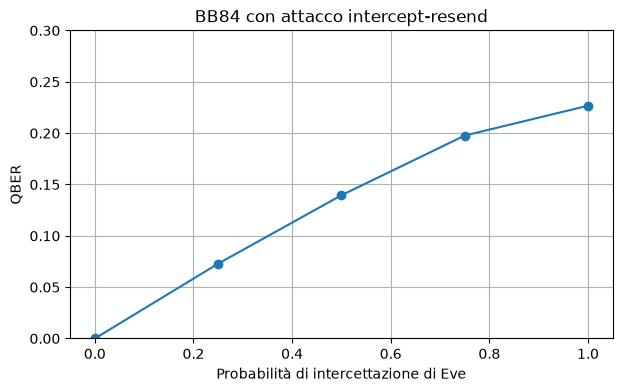

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_eve_qber_vs_interception.png


In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(
    qber_df["intercept_probability"],
    qber_df["qber"],
    marker="o",
)
plt.xlabel("Probabilità di intercettazione di Eve")
plt.ylabel("QBER")
plt.title("BB84 con attacco intercept-resend")
plt.grid(True)
plt.ylim(0, max(0.3, qber_df["qber"].max() + 0.05))

figure_path = figures_dir / "bb84_eve_qber_vs_interception.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico salvato in: {figure_path}")

Per `intercept_probability = 0` il QBER resta nullo nel caso ideale. Aumentando la probabilità di intercettazione, il QBER tende ad aumentare. Con Eve sempre attiva, il valore simulato tende ad avvicinarsi al valore teorico atteso di circa 0.25. Eventuali differenze sono dovute al carattere statistico della simulazione e al numero finito di round.